# 5. Real-time Inference — Person + Pose Pipeline

Combine the **person detector** (from `person_detector/`) and the **pose estimator** (from `keypoint_detector/models/best_model/`) into a single real-time pipeline.

```
Video frame
  ↓
Person Detector  (every N frames, tracks box between detections)
  ↓
Pose Estimator   (every frame, inside bounding box)
  ↓
Feature Engineering  → elbow_angle, body_straightness, …
  ↓
Annotated output frame
```

**Modes:**
- `4.1` — single test video (smoke test)
- `4.2` — custom video file path
- `4.3` — webcam stream (live)

**Depends on:** `person_detector` notebook 4 and `keypoint_detector` notebook 4 completed.

In [1]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['ultralytics', 'opencv-python', 'matplotlib', 'tqdm', 'numpy']:
    install(pkg)
print('Dependencies ready.')

Dependencies ready.


In [2]:
import cv2, json, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from IPython.display import clear_output, display
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT    = Path('..').resolve()
KD_DIR  = ROOT / 'keypoint_detector'
PD_DIR  = ROOT / 'person_detector'

POSE_MODEL_DIR = KD_DIR  / 'models' / 'best_model'
PD_MODEL_DIR   = PD_DIR  / 'models' / 'best_model'
OUTPUT_DIR     = KD_DIR  / 'inference_output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load model configs ────────────────────────────────────────────────────────
pose_info_path = POSE_MODEL_DIR / 'best_model_info.json'
pd_info_path   = PD_MODEL_DIR   / 'best_model_info.json'

if not pose_info_path.exists():
    raise FileNotFoundError(f'{pose_info_path}\nRun keypoint_detector notebook 4 first.')
if not pd_info_path.exists():
    raise FileNotFoundError(f'{pd_info_path}\nRun person_detector notebook 4 first.')

pose_info = json.loads(pose_info_path.read_text())
pd_info   = json.loads(pd_info_path.read_text())

POSE_CONF  = pose_info.get('conf_thresh', 0.3)
DET_CONF   = pd_info.get('conf_thresh', 0.3)
PERSON_CLS = 0

print(f'Person detector  : {pd_info["model_id"]}')
print(f'Pose estimator   : {pose_info["model_id"]}')
print(f'Person conf      : {DET_CONF}')
print(f'Pose conf        : {POSE_CONF}')

# ── Load models (once) ────────────────────────────────────────────────────────
pd_model   = YOLO(str(PD_MODEL_DIR   / 'best_model.pt'))
pose_model = YOLO(str(POSE_MODEL_DIR / 'best_model.pt'))
print('\nBoth models loaded.')

# ── Test videos ───────────────────────────────────────────────────────────────
DATA_DIR    = ROOT / 'data'
sample_vids = sorted((DATA_DIR/'correct_form').glob('*.mp4')) + \
              sorted((DATA_DIR/'wrong_form').glob('*.mp4'))
print(f'\nSample videos: {len(sample_vids)}')

Person detector  : yolo11m.pt
Pose estimator   : yolov8n-pose.pt
Person conf      : 0.3
Pose conf        : 0.3

Both models loaded.

Sample videos: 152


## 5.1 Core Pipeline Functions

In [3]:
COCO_KPS = [
    'nose','l_eye','r_eye','l_ear','r_ear',
    'l_shoulder','r_shoulder','l_elbow','r_elbow',
    'l_wrist','r_wrist','l_hip','r_hip',
    'l_knee','r_knee','l_ankle','r_ankle'
]

SKELETON = [
    (5,7),(7,9),(6,8),(8,10),          # arms
    (5,6),(5,11),(6,12),(11,12),       # torso
    (11,13),(13,15),(12,14),(14,16)    # legs
]

# Colours
C_BOX   = (0, 255, 0)      # person detector bbox
C_KP    = (0, 165, 255)    # keypoints
C_BONE  = (200, 200, 200)  # skeleton lines
C_TXT   = (255, 255, 0)    # angle text
C_INFO  = (255, 255, 255)  # info text


def angle_3pts(a, b, c):
    ba = np.array(a) - np.array(b)
    bc = np.array(c) - np.array(b)
    cos_a = np.dot(ba, bc) / (np.linalg.norm(ba)*np.linalg.norm(bc)+1e-9)
    return float(np.degrees(np.arccos(np.clip(cos_a,-1,1))))


def detect_person(frame, conf=DET_CONF):
    """
    Run person detector. Returns tightest bounding box of closest person
    as [x1,y1,x2,y2] or None.
    """
    res = pd_model(frame, conf=conf, classes=[PERSON_CLS], verbose=False)[0]
    if res.boxes is None or len(res.boxes) == 0:
        return None
    boxes = res.boxes.xyxy.cpu().numpy()
    areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
    best  = int(np.argmax(areas))
    return boxes[best].astype(int)   # [x1,y1,x2,y2]


def run_pose(frame, box=None, conf=POSE_CONF):
    """
    Run pose estimator, optionally on a cropped region.
    Returns (kps array (17,3), crop_offset (x,y)) or (None, (0,0)).
    """
    h, w = frame.shape[:2]

    if box is not None:
        x1, y1, x2, y2 = np.clip([box[0],box[1],box[2],box[3]], 0,
                                  [w,h,w,h]).astype(int)
        # Add small padding
        pad = 20
        x1 = max(0, x1-pad); y1 = max(0, y1-pad)
        x2 = min(w, x2+pad); y2 = min(h, y2+pad)
        crop  = frame[y1:y2, x1:x2]
        offset = (x1, y1)
    else:
        crop  = frame
        offset = (0, 0)

    if crop.size == 0:
        return None, offset

    res = pose_model(crop, conf=conf, verbose=False)[0]
    if res.keypoints is None or len(res.keypoints) == 0:
        return None, offset

    crop_boxes = res.boxes.xyxy.cpu().numpy()
    areas = (crop_boxes[:,2]-crop_boxes[:,0]) * (crop_boxes[:,3]-crop_boxes[:,1])
    best  = int(np.argmax(areas))
    kps   = res.keypoints.data.cpu().numpy()[best]   # (17, 3)

    # Shift coords back to full-frame space
    kps[:,0] += offset[0]
    kps[:,1] += offset[1]

    return kps, offset


def compute_features(kps, conf_thresh=POSE_CONF):
    """Compute scalar biomechanical features from (17,3) keypoints."""
    h_norm = max(kps[:,1].max(), 1)

    def pt(i):
        return kps[i,:2] if kps[i,2] > conf_thresh else None

    l_sh,r_sh = pt(5),pt(6)
    l_el,r_el = pt(7),pt(8)
    l_wr,r_wr = pt(9),pt(10)
    l_hi,r_hi = pt(11),pt(12)
    l_kn,r_kn = pt(13),pt(14)
    l_an,r_an = pt(15),pt(16)

    def sa(a,b,c): return angle_3pts(a,b,c) if all(v is not None for v in [a,b,c]) else None

    feats = {
        'left_elbow_angle' : sa(l_sh,l_el,l_wr),
        'right_elbow_angle': sa(r_sh,r_el,r_wr),
        'left_hip_angle'   : sa(l_sh,l_hi,l_kn),
        'right_hip_angle'  : sa(r_sh,r_hi,r_kn),
        'shoulder_height'  : float((l_sh[1]+r_sh[1])/2/h_norm) if l_sh is not None and r_sh is not None else None,
    }

    if l_sh is not None and l_hi is not None and l_an is not None:
        sa_vec = l_an - l_sh
        t  = np.dot(l_hi-l_sh, sa_vec) / (np.dot(sa_vec,sa_vec)+1e-9)
        proj = l_sh + t*sa_vec
        feats['body_straightness'] = float(np.linalg.norm(l_hi-proj))
    else:
        feats['body_straightness'] = None

    if feats['left_elbow_angle'] and feats['right_elbow_angle']:
        feats['elbow_symmetry'] = abs(feats['left_elbow_angle'] - feats['right_elbow_angle'])
    else:
        feats['elbow_symmetry'] = None

    return feats


def draw_pose_on_frame(frame, kps, box, feats, infer_ms, frame_idx):
    """Draw bounding box, skeleton, keypoints, and angle labels on frame."""
    out = frame.copy()
    h, w = out.shape[:2]

    # Person bbox
    if box is not None:
        cv2.rectangle(out, (box[0],box[1]), (box[2],box[3]), C_BOX, 2)

    if kps is not None:
        # Skeleton
        for a, b in SKELETON:
            if kps[a,2] > POSE_CONF and kps[b,2] > POSE_CONF:
                p1 = (int(kps[a,0]), int(kps[a,1]))
                p2 = (int(kps[b,0]), int(kps[b,1]))
                cv2.line(out, p1, p2, C_BONE, 2)

        # Keypoints
        for i in range(17):
            if kps[i,2] > POSE_CONF:
                x,y = int(kps[i,0]), int(kps[i,1])
                cv2.circle(out, (x,y), 5, C_KP, -1)
                cv2.circle(out, (x,y), 5, (255,255,255), 1)

        # Angle labels
        def draw_angle_label(kp_idx, angle_val, label):
            if angle_val is None: return
            if kps[kp_idx,2] <= POSE_CONF: return
            x,y = int(kps[kp_idx,0])+8, int(kps[kp_idx,1])
            cv2.putText(out, f'{label}:{angle_val:.0f}', (x,y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, C_TXT, 1, cv2.LINE_AA)

        draw_angle_label(7,  feats.get('left_elbow_angle'),  'L')
        draw_angle_label(8,  feats.get('right_elbow_angle'), 'R')
        draw_angle_label(11, feats.get('left_hip_angle'),    'Lhip')

    # HUD
    hud_lines = [
        f'Frame: {frame_idx}',
        f'Pose : {infer_ms:.0f}ms',
        f'L-elbow: {feats.get("left_elbow_angle","?"):.0f}°' if feats.get('left_elbow_angle') else 'L-elbow: --',
        f'R-elbow: {feats.get("right_elbow_angle","?"):.0f}°' if feats.get('right_elbow_angle') else 'R-elbow: --',
        f'Straight: {feats.get("body_straightness","?"):.1f}px' if feats.get('body_straightness') else 'Straight: --',
    ]
    for i, line in enumerate(hud_lines):
        cv2.putText(out, line, (10, 25+i*20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, C_INFO, 1, cv2.LINE_AA)

    return out


print('Pipeline functions ready.')

Pipeline functions ready.


## 5.2 Smoke Test — Single Video

Run first sample video through the pipeline and show annotated frames.

In [4]:
# ── Config ────────────────────────────────────────────────────────────────────
DETECT_EVERY_N = 10      # run person detector every N frames (saves compute)
MAX_FRAMES     = 120     # frames to preview in notebook
SHOW_EVERY_N   = 15      # show 1 frame every N (reduces display clutter)

if not sample_vids:
    raise FileNotFoundError('No sample videos found in data/correct_form or data/wrong_form')

test_video = str(sample_vids[0])
print(f'Testing : {test_video}')

cap          = cv2.VideoCapture(test_video)
frame_idx    = 0
current_box  = None   # cached person bbox
preview_imgs = []
det_times    = []
pose_times   = []

while cap.isOpened() and frame_idx < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret: break

    # ── Person detection (sparse) ──
    if frame_idx % DETECT_EVERY_N == 0:
        t0 = time.perf_counter()
        current_box = detect_person(frame)
        det_times.append((time.perf_counter()-t0)*1000)

    # ── Pose estimation (every frame) ──
    t0 = time.perf_counter()
    kps, _ = run_pose(frame, current_box)
    pose_ms = (time.perf_counter()-t0)*1000
    pose_times.append(pose_ms)

    # ── Features ──
    feats = compute_features(kps) if kps is not None else {}

    # ── Annotate ──
    vis = draw_pose_on_frame(frame, kps, current_box, feats, pose_ms, frame_idx)

    if frame_idx % SHOW_EVERY_N == 0:
        preview_imgs.append(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))

    frame_idx += 1

cap.release()
print(f'Processed {frame_idx} frames')
print(f'Avg person detect: {np.mean(det_times):.1f}ms  pose: {np.mean(pose_times):.1f}ms')
print(f'Effective FPS (pose only): {1000/np.mean(pose_times):.1f}')

Testing : /Users/haleytran/Downloads/pushup_judge/data/correct_form/Copy of push up 1.mp4
Processed 61 frames
Avg person detect: 147.9ms  pose: 28.1ms
Effective FPS (pose only): 35.6


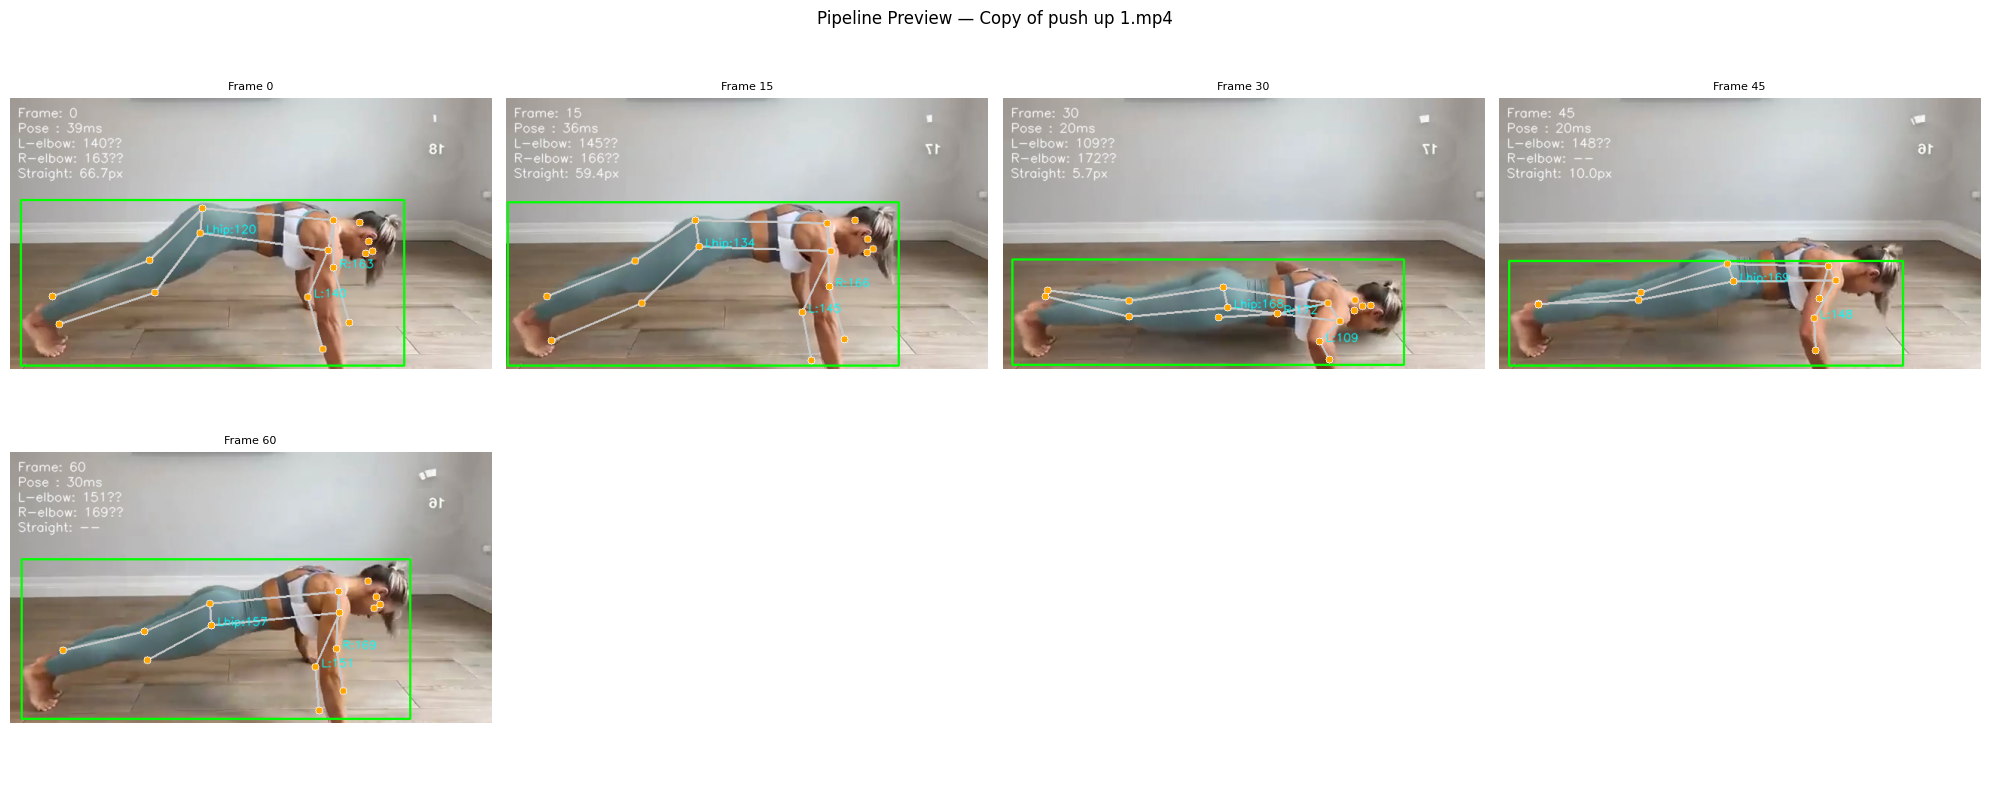

In [5]:
# Display preview grid
n = len(preview_imgs)
cols = 4
rows = max(1, (n + cols - 1) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.array(axes).flatten()

for i, ax in enumerate(axes):
    if i < n:
        ax.imshow(preview_imgs[i])
        ax.set_title(f'Frame {i*SHOW_EVERY_N}', fontsize=8)
    ax.axis('off')

fig.suptitle(f'Pipeline Preview — {Path(test_video).name}', fontsize=12)
plt.tight_layout()
plt.show()

## 5.3 Save Annotated Output Video

Process a full video and write annotated output to `inference_output/`.

In [6]:
def process_video(video_path: str, output_dir: Path,
                  detect_every: int = 10, max_frames: int = None) -> dict:
    """
    Run full pipeline on a video file and write annotated output.
    Returns performance stats dict.
    """
    video_path = str(video_path)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return {'error': f'Cannot open {video_path}'}

    fps_in = cap.get(cv2.CAP_PROP_FPS) or 30
    w_in   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h_in   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    stem    = Path(video_path).stem
    out_path = output_dir / f'{stem}_pose.mp4'
    writer  = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*'mp4v'),
                               fps_in, (w_in, h_in))

    frame_idx     = 0
    current_box   = None
    pose_times    = []
    det_count     = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        if max_frames and frame_idx >= max_frames: break

        if frame_idx % detect_every == 0:
            current_box = detect_person(frame)
            det_count += 1

        t0 = time.perf_counter()
        kps, _ = run_pose(frame, current_box)
        pose_times.append((time.perf_counter()-t0)*1000)

        feats = compute_features(kps) if kps is not None else {}
        vis   = draw_pose_on_frame(frame, kps, current_box, feats,
                                   pose_times[-1], frame_idx)
        writer.write(vis)
        frame_idx += 1

    cap.release(); writer.release()

    return {
        'output'      : str(out_path),
        'frames'      : frame_idx,
        'avg_pose_ms' : round(float(np.mean(pose_times)), 1) if pose_times else 0,
        'det_calls'   : det_count,
    }


# Run on first sample video
if sample_vids:
    stats = process_video(sample_vids[0], OUTPUT_DIR, detect_every=DETECT_EVERY_N)
    print('Output stats:', json.dumps(stats, indent=2))
else:
    print('[SKIP] No sample videos.')

Output stats: {
  "output": "/Users/haleytran/Downloads/pushup_judge/keypoint_detector/inference_output/Copy of push up 1_pose.mp4",
  "frames": 61,
  "avg_pose_ms": 30.9,
  "det_calls": 7
}


## 5.4 Custom Video

Point to any video file you want to analyse.

In [7]:
# ── EDIT THIS PATH ────────────────────────────────────────────────────────────
CUSTOM_VIDEO = ''   # e.g. '/path/to/my_pushup.mp4'
# ─────────────────────────────────────────────────────────────────────────────

if CUSTOM_VIDEO and Path(CUSTOM_VIDEO).exists():
    stats = process_video(CUSTOM_VIDEO, OUTPUT_DIR, detect_every=10)
    print('Output stats:', json.dumps(stats, indent=2))
else:
    print('Set CUSTOM_VIDEO path above and re-run.')

Set CUSTOM_VIDEO path above and re-run.


## 5.5 Webcam Live Stream

> ⚠️ Requires webcam access. Press **Q** in the OpenCV window to stop.

In [8]:
# Uncomment to enable webcam

# WEBCAM_ID      = 0
# DETECT_EVERY_N = 10
#
# cap = cv2.VideoCapture(WEBCAM_ID)
# if not cap.isOpened():
#     print('[ERROR] Cannot open webcam.')
# else:
#     current_box = None
#     frame_idx   = 0
#     print('Webcam running — press Q in window to stop.')
#     while True:
#         ret, frame = cap.read()
#         if not ret: break
#
#         if frame_idx % DETECT_EVERY_N == 0:
#             current_box = detect_person(frame)
#
#         kps, _ = run_pose(frame, current_box)
#         feats  = compute_features(kps) if kps is not None else {}
#         vis    = draw_pose_on_frame(frame, kps, current_box, feats, 0, frame_idx)
#
#         cv2.imshow('PushUp Pose Estimator', vis)
#         if cv2.waitKey(1) & 0xFF == ord('q'):
#             break
#         frame_idx += 1
#
#     cap.release()
#     cv2.destroyAllWindows()
#     print('Webcam stopped.')

print('Webcam cell ready — uncomment code above to run.')

Webcam cell ready — uncomment code above to run.


## 5.6 Performance Summary

In [9]:
print('=== Pipeline Performance Summary ===')
print(f'Person Detector  : {pd_info["model_id"]}')
print(f'Pose Estimator   : {pose_info["model_id"]}')
print()

if det_times and pose_times:
    print(f'Avg person detect  : {np.mean(det_times):.1f} ms  (runs every {DETECT_EVERY_N} frames)')
    print(f'Avg pose estimate  : {np.mean(pose_times):.1f} ms  (every frame)')
    effective_ms = np.mean(pose_times) + np.mean(det_times)/DETECT_EVERY_N
    print(f'Effective latency  : {effective_ms:.1f} ms/frame  →  {1000/effective_ms:.1f} FPS')

print('\nOutput files:')
for f in sorted(OUTPUT_DIR.glob('*.mp4')):
    print(f'  {f.name}  ({f.stat().st_size/1024:.1f} KB)')

print('\n✅ Stage 2 complete — pose estimator pipeline ready.')
print('Next stage → feature_engineering / rep_segmentation notebooks.')

=== Pipeline Performance Summary ===
Person Detector  : yolo11m.pt
Pose Estimator   : yolov8n-pose.pt

Avg person detect  : 147.9 ms  (runs every 10 frames)
Avg pose estimate  : 28.1 ms  (every frame)
Effective latency  : 42.9 ms/frame  →  23.3 FPS

Output files:
  Copy of push up 1_pose.mp4  (754.0 KB)

✅ Stage 2 complete — pose estimator pipeline ready.
Next stage → feature_engineering / rep_segmentation notebooks.
